<a href="https://colab.research.google.com/github/Victor-lesufi/-Desktop-Projects-uj-layout/blob/gh-pages/sbank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
from PIL import Image
folder_path = '/content/drive/My Drive/test_data/test_data'

Mounted at /content/drive


In [16]:
!pip install torch torchvision transformers pillow


In [17]:
import os
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import CLIPProcessor, CLIPModel


In [18]:
# Load the CLIP model and processor
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [19]:
def load_images(folder_path):
    images = []
    image_paths = []

    for file in os.listdir(folder_path):
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(folder_path, file)
            image = Image.open(img_path).convert("RGB")  # Convert to RGB mode
            images.append(image)
            image_paths.append(img_path)

    return images, image_paths

folder_path = "/content/drive/My Drive/test_data/test_data"
images, image_paths = load_images(folder_path)


In [20]:
def extract_image_features(images):
    image_inputs = processor(images=images, return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = model.get_image_features(**image_inputs)

    return image_features / image_features.norm(dim=-1, keepdim=True)  # Normalize embeddings

image_features = extract_image_features(images)


In [21]:
def encode_text_query(text_query):
    text_inputs = processor(text=[text_query], return_tensors="pt").to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)

    return text_features / text_features.norm(dim=-1, keepdim=True)  # Normalize embeddings


In [22]:
def retrieve_top_k_images(text_query, image_features, image_paths, k=5):
    text_embedding = encode_text_query(text_query)  # Get text embedding
    similarities = (image_features @ text_embedding.T).squeeze(1)  # Compute cosine similarity
    top_k_indices = similarities.argsort(descending=True)[:k]  # Get top-K matches

    top_k_images = [image_paths[i] for i in top_k_indices]
    return top_k_images


In [23]:
query = "a cat sitting on a table"  # Example query
top_k_images = retrieve_top_k_images(query, image_features, image_paths, k=5)

print("Top Matching Images:")
for img in top_k_images:
    print(img)


Top Matching Images:
/content/drive/My Drive/test_data/test_data/3f655b8dfb5449af9fb7044eb642c293.jpg
/content/drive/My Drive/test_data/test_data/4aa7873c25c645569ee998ae6a6f528f.jpg
/content/drive/My Drive/test_data/test_data/1d8a806be7c644259c7591bfc09146dc.jpg
/content/drive/My Drive/test_data/test_data/2b6bbc20f8574e4fab5577ae96b306b4.jpg
/content/drive/My Drive/test_data/test_data/3e5e04c6239d4e61baeac66379c3deef.jpg


Top Matching images:


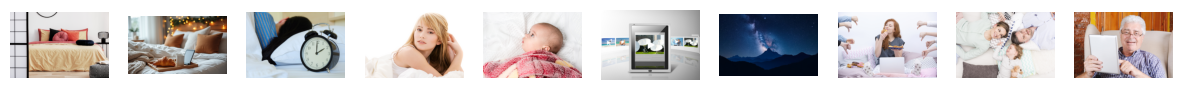

In [41]:
import os
from PIL import Image
import torch
from transformers import CLIPProcessor, CLIPModel
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Step 1: Load the CLIP model and processor
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

# Step 2: Define the folder path and load images
folder_path = '/content/drive/My Drive/test_data/test_data'
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

images = []
for img_file in image_files:
    img_path = os.path.join(folder_path, img_file)
    image = Image.open(img_path).convert("RGB")
    images.append(image)

image_inputs = processor(images=images, return_tensors="pt", padding=True)

# Step 3: Generate image embeddings
with torch.no_grad():
    image_features = model.get_image_features(**image_inputs)
image_embeddings = image_features / image_features.norm(p=2, dim=-1, keepdim=True)

# Step 4: Define function to get top-K images
def retrieve_top_k_images(text_query, image_embeddings, image_paths, k=10):
    # Preprocess the text query
    text_inputs = processor(text=text_query, return_tensors="pt", padding=True)

    # Generate text embedding
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)
    text_embedding = text_features / text_features.norm(p=2, dim=-1, keepdim=True)  # Normalize embedding

    # Compute cosine similarity between text and image embeddings
    similarities = cosine_similarity(text_embedding.cpu().numpy(), image_embeddings.cpu().numpy())

    # Get indices of top-k similar images
    top_k_indices = np.argsort(similarities[0])[::-1][:k]

    # Return the top-k image file names
    top_k_images = [image_paths[i] for i in top_k_indices]
    return top_k_images

# Step 5: Display the images
def display_images(top_k_images, folder_path):
    num_images = len(top_k_images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i, img_name in enumerate(top_k_images):
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')  # Turn off axis labels

    plt.show()

# Step 6: Test the function
query = "retrieve images with bed"  # Example query
k = 10
top_k_images = retrieve_top_k_images(query, image_embeddings, image_files, k=k)

print("Top Matching images:")
display_images(top_k_images, folder_path)